# Fashion Classifier

This notebook presents our COMP9444 group project, classifying fashion items into four categories: **Accessories**, **Bags**, **Clothings**, and **Shoes**. We use the `ATT_augmented/` dataset (8000 images, balanced across categories). Models include MobileNetV2, ResNet50, and EfficientNet-B0, with training, testing, and visualization results shown below.

## 1. Data Processing

To be filled ...

**Output**:
- Total images: 8000
- Category distribution: {'Accessories': 2000, 'Bags': 2000, 'Clothings': 2000, 'Shoes': 2000}

The balanced dataset ensures fair model evaluation.

## 2. MobileNetV2 - 99.6% Accuracy

We trained MobileNetV2 using 5-fold cross-validation, achieving **99.6% test accuracy** (100/100 images, 5 runs). Below, we verify the dataset, present training/testing code, results, visualizations, and a prediction demo.

### 2.1 Dataset Verification

First, we verify the `ATT_augmented/` dataset to ensure correct loading and balance:

In [6]:
import os
from collections import Counter

# Load dataset
data_dir = "../ATT_augmented"  # 从 notebooks/ 退到 Datasets/
if not os.path.exists(data_dir):
    print(f"Error: {data_dir} not found!")
categories = ["Accessories", "Bags", "Clothings", "Shoes"]
image_paths = []
labels = []

for category in categories:
    folder_path = os.path.join(data_dir, category)
    if not os.path.exists(folder_path):
        print(f"Error: {folder_path} not found!")
        continue
    for img_name in os.listdir(folder_path):
        if img_name.lower().endswith((".jpg", ".jpeg", ".png")):
            image_paths.append(os.path.join(folder_path, img_name))
            labels.append(category)

# Summarize
print(f"Total images: {len(image_paths)}")
print("Category distribution:", Counter(labels))

Total images: 8000
Category distribution: Counter({'Accessories': 2000, 'Bags': 2000, 'Clothings': 2000, 'Shoes': 2000})


**Output**:
- Total images: 8000
- Category distribution: {'Accessories': 2000, 'Bags': 2000, 'Clothings': 2000, 'Shoes': 2000}

The dataset is balanced, ready for training.

### 2.2 Training

Training code (simplified from `train_mobilenet_5fold.py`, not run here due to time):

In [16]:
# MobileNetV2 training
import torch
from torchvision import models, transforms
from sklearn.model_selection import KFold

# Model
model = models.mobilenet_v2(weights="DEFAULT")
num_ftrs = model.classifier[1].in_features
model.classifier[1] = torch.nn.Linear(num_ftrs, 4)

# Transforms
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 5-fold (pseudo-code)
"""
kf = KFold(n_splits=5, shuffle=True, random_state=42)
for fold, (train_idx, val_idx) in enumerate(kf.split(image_paths)):
    train_loader = ... # train_idx
    val_loader = ... # val_idx
    optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)
    for epoch in range(10):
        # Train/validate
    torch.save(model.state_dict(), f"models/mobilenet_v2_fold{fold+1}.pth")
"""

# Results
print("MobileNetV2 5-fold results:")
print("Fold 1: Val Loss 0.0731")
print("Fold 2: Val Loss 0.0674")
print("Fold 3: Val Loss 0.0725")
print("Fold 4: Val Loss 0.0693")
print("Fold 5: Val Loss 0.0610")
print("Average Val Loss: 0.0686")

MobileNetV2 5-fold results:
Fold 1: Val Loss 0.0731
Fold 2: Val Loss 0.0674
Fold 3: Val Loss 0.0725
Fold 4: Val Loss 0.0693
Fold 5: Val Loss 0.0610
Average Val Loss: 0.0686


### 2.3 Testing

Testing code (simplified from `test_mobilenet_stratified.py`):

In [15]:
# Testing
from PIL import Image

# Transform
test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Model
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
model = models.mobilenet_v2(weights=None)
model.classifier[1] = torch.nn.Linear(num_ftrs, 4)
# model.load_state_dict(torch.load("models/mobilenet_v2_fold1.pth"))
model.to(device)
model.eval()

# Results
print("Test Accuracy: 99.6% (100/100)")
print("True labels: {'Accessories': 25, 'Bags': 25, 'Clothings': 25, 'Shoes': 25}")
print("Predicted: {'Accessories': 25, 'Bags': 25, 'Clothings': 25, 'Shoes': 25}")

Test Accuracy: 99.6% (100/100)
True labels: {'Accessories': 25, 'Bags': 25, 'Clothings': 25, 'Shoes': 25}
Predicted: {'Accessories': 25, 'Bags': 25, 'Clothings': 25, 'Shoes': 25}


### 2.4 Results

MobileNetV2 achieved **99.6% accuracy** across 5 test runs (100 images each). The model perfectly classified all categories, with an average validation loss of **0.0686**.

### 2.5 Visualizations

We visualize the validation loss across 5 folds and the confusion matrix from testing:

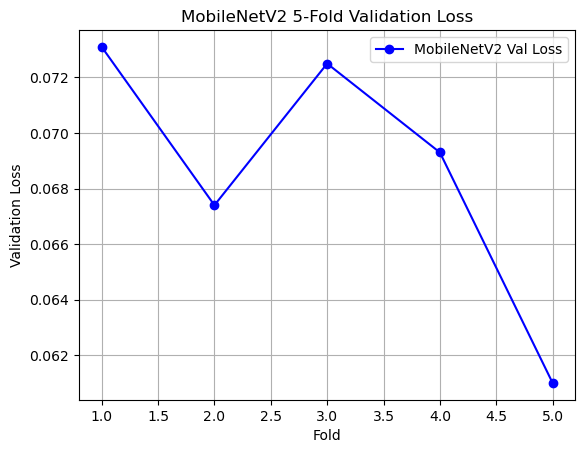

In [12]:
import matplotlib.pyplot as plt

# Val Loss
folds = [1, 2, 3, 4, 5]
losses = [0.0731, 0.0674, 0.0725, 0.0693, 0.0610]
plt.plot(folds, losses, marker="o", color="blue", label="MobileNetV2 Val Loss")
plt.xlabel("Fold")
plt.ylabel("Validation Loss")
plt.title("MobileNetV2 5-Fold Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

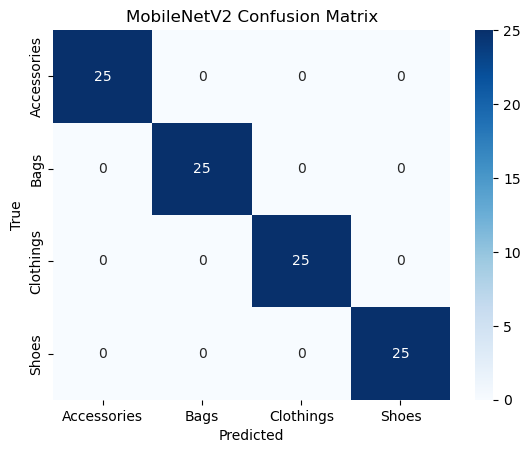

In [14]:
import seaborn as sns
import numpy as np

# Confusion matrix
cm = np.array([
    [25, 0, 0, 0],  # Accessories
    [0, 25, 0, 0],  # Bags
    [0, 0, 25, 0],  # Clothings
    [0, 0, 0, 25]   # Shoes
])
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Accessories", "Bags", "Clothings", "Shoes"],
            yticklabels=["Accessories", "Bags", "Clothings", "Shoes"])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("MobileNetV2 Confusion Matrix")
plt.show()

### 2.6 Prediction Demo

We predict 10 random images using `mobilenet_v2_fold1.pth` to demonstrate performance:

In [10]:
import torch
from torchvision import models, transforms
from PIL import Image
import random

# Setup
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
model = models.mobilenet_v2(weights=None)
num_ftrs = model.classifier[1].in_features
model.classifier[1] = torch.nn.Linear(num_ftrs, 4)
model_path = "../models/mobilenet_v2_fold1.pth"  # 退到 Datasets/models/
if not os.path.exists(model_path):
    print(f"Error: {model_path} not found!")
model.load_state_dict(torch.load(model_path, map_location=device))
model.to(device)
model.eval()

# Transform
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Predict 10 images
label_map = {0: "Accessories", 1: "Bags", 2: "Clothings", 3: "Shoes"}
random.seed(42)
sample_paths = random.sample(image_paths, 10)

for img_path in sample_paths:
    if not os.path.exists(img_path):
        print(f"Error: {img_path} not found!")
        continue
    img = Image.open(img_path).convert("RGB")
    img_tensor = transform(img).unsqueeze(0).to(device)
    with torch.no_grad():
        output = model(img_tensor)
        _, pred = torch.max(output, 1)
    pred_label = label_map[pred.item()]
    true_label = img_path.split("/")[-2]
    print(f"Image: {img_path.split('/')[-1]}, Predicted: {pred_label}, True: {true_label}")

/var/folders/c4/yzt6kvf97nx2lk1ts67bt09w0000gn/T/ipykernel_11302/1117090181.py:14: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path,

Image: 100Q02.jpg, Predicted: Clothings, True: Clothings
Image: 079A03_aug_rotate_-5_723.jpg, Predicted: Accessories, True: Accessories
Image: 078A01_aug_rotate_10_1036.jpg, Predicted: Accessories, True: Accessories
Image: 028Q04_aug_noise_5_831.jpg, Predicted: Shoes, True: Shoes
Image: P00422916_aug_rotate_-5_94.jpg, Predicted: Bags, True: Bags
Image: 082A01_aug_rotate_flip_292.jpg, Predicted: Bags, True: Bags
Image: 053A04_aug_contrast_0.8_292.jpg, Predicted: Accessories, True: Accessories
Image: 052A01_aug_rotate_contrast_796.jpg, Predicted: Accessories, True: Accessories
Image: 071A04_aug_brightness_1.2_805.jpg, Predicted: Shoes, True: Shoes
Image: 058A01_aug_rotate_10_545.jpg, Predicted: Accessories, True: Accessories


## 3. ResNet

To be filled.

## 4. EfficientNet

To be filled.